<a href="https://colab.research.google.com/github/sherlyazkiah/PCVK/blob/main/Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

No 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


No 2

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

No 3

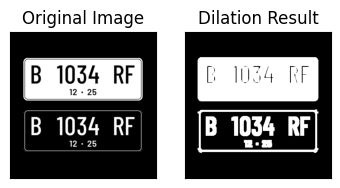

In [ ]:
# Dilation without library
def dilasi_citra(F, w):
    # image size
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structure element dilasi (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2

    # Dilation process
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

img_d = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 4

[[1 1 1]
 [1 1 1]
 [1 1 1]]


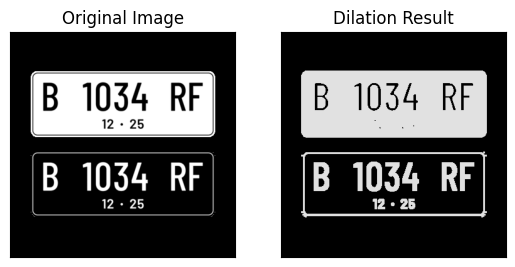

In [ ]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png')
# img = cv2.imread('morp.jpg', 0)

ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3), np.uint16)
dilation = cv2.dilate(thresh, kernel, iterations=1)

print(kernel)

plt.subplot(121), plt.imshow(img), plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dilation), plt.title('Dilation Result')
plt.xticks([]), plt.yticks([])
plt.show()

No 5

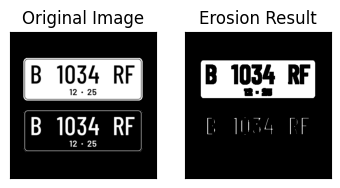

In [ ]:
# Erosion without library
def erosi_citra(F, k):
    # image size
    m, n = F.shape

    # Generate structure element erosi (SE)
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Erosion process
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY)
k = 5
imgE = erosi_citra(thresh1, k)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 6

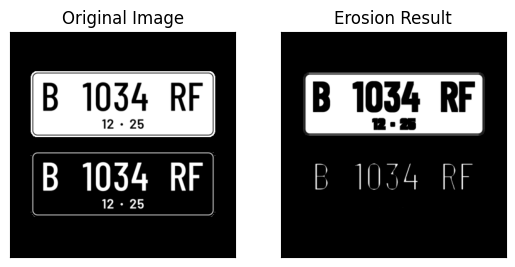

In [ ]:
# EROSION USING LIBRARY
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png')

kernel = np.ones((5,5), np.uint8)
erosion = cv2.erode(img, kernel, iterations=1)

plt.subplot(121), plt.imshow(img), plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(erosion), plt.title('Erosion Result')
plt.xticks([]), plt.yticks([])
plt.show()

No 7

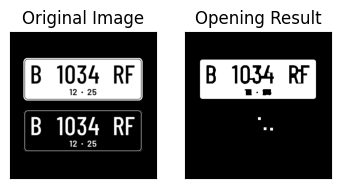

In [ ]:
# Opening Operation Without Library (Morphology)
img_o = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
reto, thresho = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY)
k = 7
imgO = dilasi_citra(erosi_citra(thresho, k), k)

plt.subplot(131), plt.imshow(img_o, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgO, cmap='gray')
plt.title('Opening Result'), plt.xticks([]), plt.yticks([])
plt.show()

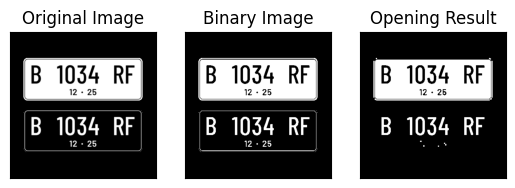

In [ ]:
#Opening Operation Using Library (Morphology)
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3), np.uint8)
openn = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Binary Image'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(openn, cmap='gray')
plt.title('Opening Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 8

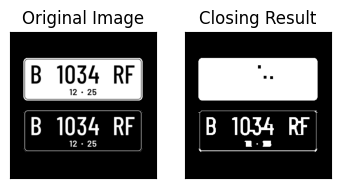

In [ ]:
# Closing Operation Without Library (Morphology)
img_c = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
retc, threshc = cv2.threshold(img_c, 127, 225, cv2.THRESH_BINARY)
k = 7
imgC = erosi_citra(dilasi_citra(threshc, k), k)

plt.subplot(131), plt.imshow(img_c, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgC, cmap='gray')
plt.title('Closing Result'), plt.xticks([]), plt.yticks([])
plt.show()

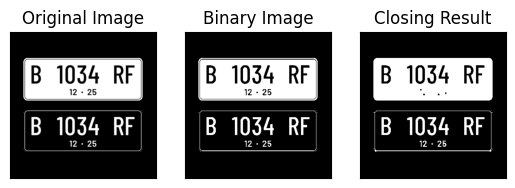

In [ ]:
# Closing Operation Using Library (Morphology)
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3), np.uint8)
closs = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Binary Image'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(closs, cmap='gray')
plt.title('Closing Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 9

SED = Cross 3


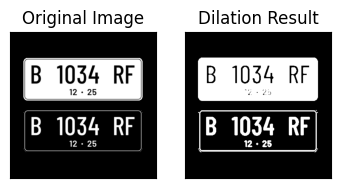

SED = Cross 5


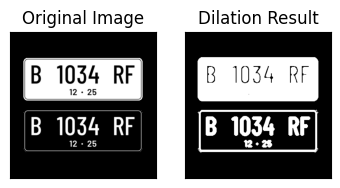

In [ ]:
# Dilation with Cross Structuring Element (SED)
def dilasi_citra(F, w):
    # image size
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structuring element for dilation (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    SED = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=np.uint8)
    constant1 = (w - 1) // 2

    # Dilation process
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

print('SED = Cross 3')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()


# Dilation with Larger Cross Structuring Element (SED)
def dilasi_citra(F, w):
    # image size
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structuring element for dilation (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    SED = np.array([[0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0],
                    [1, 1, 1, 1, 1],
                    [0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)
    constant1 = (w - 1) // 2

    # Dilation process
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

print('SED = Cross 5')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()


No 10

SED = Circle 3


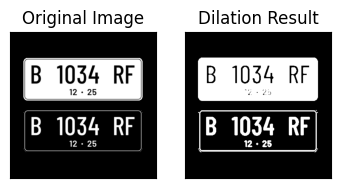

SED = Circle 5


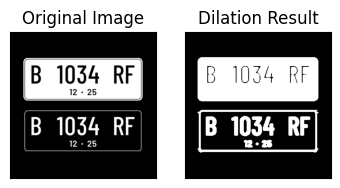

In [ ]:
# Dilation with Circular Structuring Element (SED)
def dilasi_citra(F, w):
    # image size
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structuring element for dilation (SED)
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))
    constant1 = (w - 1) // 2

    # Dilation process
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD

print('SED = Circle 3')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

print('SED = Circle 5')
img_d = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 11

SE = Rectangle 3x5


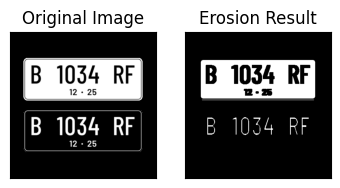

SE = Rectangle 5x7


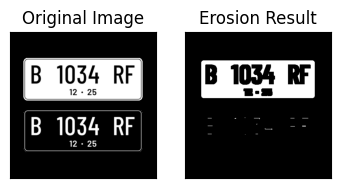

In [ ]:
# Erosion with Rectangle Structuring Element
def erosi_citra(F, p, l):
    # image size
    m, n = F.shape

    # Generate rectangular structuring element (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))
    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Erosion process
    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

print('SE = Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p = 5
l = 3
imgE = erosi_citra(thresh1, p, l)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

print('SE = Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p = 7
l = 5
imgE = erosi_citra(thresh1, p, l)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 12

SE = Vertical Line 3


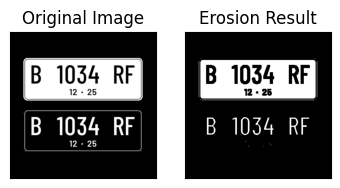

SE = Vertical Line 5


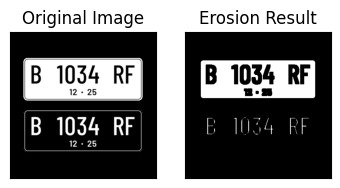

In [ ]:
# Erosion with Vertical Line Structuring Element (SE)
def erosi_citra(F, k):
    # image size
    m, n = F.shape

    # Generate structuring element for erosion (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, k)) # vertical line SE
    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Erosion process
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)
    return imgE

print('SE = Vertical Line 3')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k = 3
imgE = erosi_citra(thresh1, k)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

print('SE = Vertical Line 5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK/Images/plat.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k = 5
imgE = erosi_citra(thresh1, k)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 13

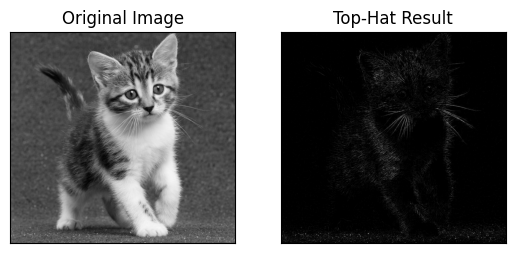

In [ ]:
# Getting the kernel to be used in Top-Hat operation
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Reading the image
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/kitten00.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Top-Hat operation
tophat_img = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(tophat_img, cmap='gray')
plt.title('Top-Hat Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 14

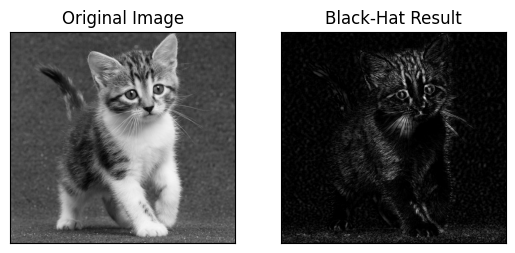

In [ ]:
# Define the kernel to be used in the Black-Hat operation
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Read the image
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/kitten00.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply the Black-Hat operation
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, Kernel)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(blackhat, cmap='gray')
plt.title('Black-Hat Result'), plt.xticks([]), plt.yticks([])
plt.show()

No 15

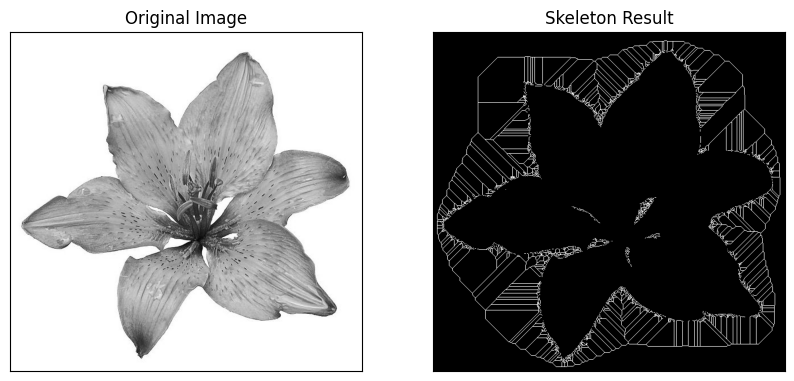

In [62]:
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# Read the image in grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg', 0)

# Apply Triangle thresholding to create a binary image
binary = img > filters.threshold_triangle(img)

# Convert boolean values (True/False) to integers (1/0)
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# Perform skeletonization on the binary image
skeleton = skeletonize(binary_cp)

# Display the original and skeletonized images
plt.figure(figsize=(10, 10))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton Result'), plt.xticks([]), plt.yticks([])

# Save the output
plt.savefig("binary and bin_skeleton.png")
plt.show()

No 16

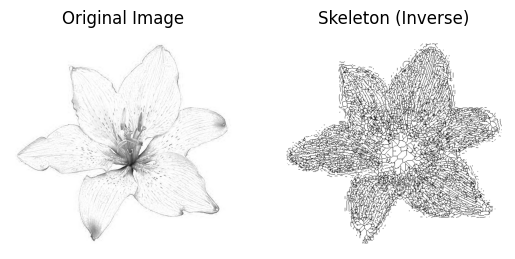

In [ ]:
from skimage import io
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# Read the image (take only the first channel)
img = io.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg')[..., 0]

# Note: we want the dark (black) regions to be True, so we use '<' instead of '>'
binary = img < filters.threshold_triangle(img)

# Perform skeletonization
skeleton = skeletonize(binary)

# Display the original and skeletonized images
fig, ax = plt.subplots(1, 2)

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].set_axis_off()

# Note the reversed colormap (gray_r) for inverted display
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('Skeleton (Inverse)')
ax[1].set_axis_off()
plt.show()

No 17

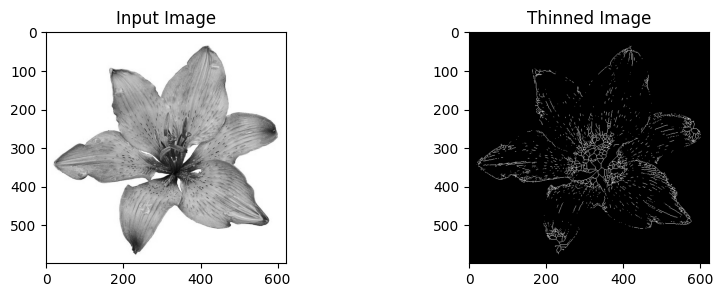

In [ ]:
from skimage import img_as_float, io, color, morphology
import matplotlib.pyplot as plt

# Read the image and convert it to grayscale and floating-point format
image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/PCVK/Images/lily.jpg')))

# Create a binary image using a threshold value
image_binary = image < 0.5

# Apply morphological operations: skeletonization and thinning
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)

# Display the input and thinned images
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))

ax0.imshow(image, cmap='gray')
ax0.set_title('Input Image')

ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thinned Image')

# Save and show the result
plt.savefig('/tmp/char_out.png')
plt.show()